# **Дослідження ефективності контрастивних представлень у напівкерованому навчанні**
## *Мета коду:*
Дослідити вплив контрастивного навчання (SimCLR) на якість класифікації зображень в умовах обмеженої кількості розмічених даних (1000 та 4500 прикладів).

## *Ключові результати:*
Підтверджено гіпотезу: використання контрастивного претренування (SimCLR) у поєднанні з PI-моделлю дозволяє досягти точності 0.692 при 1000 мітках, що суттєво перевищує базовий керований підхід (Supervised) на 4500 мітках (0.594).
Запропонований підхід забезпечує приріст точності на +6% навіть при навчанні "з нуля" (PI-Scratch) та на +25% при використанні претренованого енкодера порівняно з базовим Supervised learning (для 1000 міток).

Висновок: контрастивне навчання формує семантично багаті ознаки, які є критично важливими для стабільності напівкерованого навчання в умовах малих вибірок.






### **Імпорт бібліотек, підготовка середовища**

In [46]:
# --- імпорт необхідних бібліотек та модулів ---
import os, math, time, random
from dataclasses import dataclass
from pathlib import Path
from itertools import cycle

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, Subset

from torchvision.datasets import STL10
from torchvision import models

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score

# перевірка доступності GPU для прискорення обчислень
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- налаштування генератора випадкових чисел для відтворюваності експериментів ---
def get_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # оптимізація роботи GPU
    torch.backends.cudnn.benchmark = True

SEED = 42
get_seed(SEED)
device

device(type='cuda')

### **Конфігурація**

In [47]:
# --- конфігурація гіперпараметрів ---
@dataclass
class CFG:
    data_root: str = "./data"

    # кількість епох для різних сценаріїв навчання
    epochs_pi_4500: int = 20      # PI-model на 4500 розмічених прикладах
    epochs_sup_1000: int = 30     # Supervised навчання на 1000 прикладах
    epochs_pi_1000: int = 30      # PI-model на 1000 прикладах

    # швидкість навчання (Learning Rate) для класифікатора
    lr_head: float = 1e-3

    # вага некерованої функції втрат для PI-model (Consistency Loss)
    pi_max_w: float = 30.0

    # архітектурні параметри
    num_classes: int = 10         # кількість класів у STL-10
    projection_dim: int = 128     # розмірність проєкційного шару

    # шлях до попередньо навчених ваг SimCLR (з Google Drive)
    simclr_ckpt_path: str = "/content/drive/MyDrive/simclr_pretrained.pth"

# ініціалізація конфігурації
cfg = CFG()
cfg

CFG(data_root='./data', epochs_pi_4500=20, epochs_sup_1000=30, epochs_pi_1000=30, lr_head=0.001, pi_max_w=30.0, num_classes=10, projection_dim=128, simclr_ckpt_path='/content/drive/MyDrive/simclr_pretrained.pth')

In [48]:
# --- визначення трансформацій зображень ---
# використовується статистика ImageNet для нормалізації (середнє та стандартне відхилення)
IM_MEAN = (0.485, 0.456, 0.406)
IM_STD  = (0.229, 0.224, 0.225)

# трансформації для тренувального набору: включають випадкове кадрування та віддзеркалення
# для покращення узагальнюючої здатності моделі (data augmentation)
train_transform = T.Compose([
    T.RandomResizedCrop(96, scale=(0.8, 1.0), antialias=True),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(IM_MEAN, IM_STD),
])

# для тестового набору застосовано лише стандартну нормалізацію
test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(IM_MEAN, IM_STD),
])

In [49]:
# --- класи для роботи з даними в рамках самокерованого навчання ---

class PiModelDataset(Dataset):
    """Повертає два стохастичні погляди (аугментації) на одне зображення та його мітку"""
    def __init__(self, base_dataset, transform):
        self.dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        img, y = self.dataset[index]  # отримання оригінального PIL-зображення
        x1 = self.transform(img)      # перша випадкова аугментація
        x2 = self.transform(img)      # друга випадкова аугментація
        return x1, x2, y

class SingleViewSubset(Dataset):
    """Обгортка для застосування трансформації до підмножини даних"""
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, i):
        img, y = self.subset[i]
        x = self.transform(img)
        return x, y

### **Завантаження та перевірка даних**

In [50]:
# --- завантаження та підготовка датасету STL-10 ---
Path(cfg.data_root).mkdir(parents=True, exist_ok=True)

# завантаження частин датасету (без початкових трансформацій)
labeled_train_full = STL10(root=cfg.data_root, split="train", download=True, transform=None)     # 5000 прикладів
unlabeled_base     = STL10(root=cfg.data_root, split="unlabeled", download=True, transform=None) # 100,000 прикладів
test_ds            = STL10(root=cfg.data_root, split="test", download=True, transform=test_transform) # 8000 прикладів

# статистична перевірка даних
y_full = np.array(labeled_train_full.labels)
num_classes = int(y_full.max() + 1)

print("Розмір розміченого тренувального набору:", len(labeled_train_full))
print("Розмір нерозміченого набору:", len(unlabeled_base))
print("Розмір тестового набору:", len(test_ds))
print("Розподіл класів у тренувальній вибірці:", np.bincount(y_full, minlength=num_classes))

Розмір розміченого тренувального набору: 5000
Розмір нерозміченого набору: 100000
Розмір тестового набору: 8000
Розподіл класів у тренувальній вибірці: [500 500 500 500 500 500 500 500 500 500]


In [51]:
# --- розділення даних на навчальну та валідаційну вибірки ---
import pandas as pd

# розподіл 5000 прикладів на: 4500 для навчання та 500 для валідації
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED)
X_dummy = np.zeros((len(y_full), 1))
train_idx_4500, val_idx_500 = next(sss.split(X_dummy, y_full))

train_idx_4500 = np.array(train_idx_4500)
val_idx_500 = np.array(val_idx_500)

print(f"Розмір тренувального набору (4500): {len(train_idx_4500)}")
print(f"Розмір валідаційного набору (500): {len(val_idx_500)}")

# --- створення підмножини на 1000 прикладів із 4500 ---
y_pool = y_full[train_idx_4500]
sss_1k = StratifiedShuffleSplit(n_splits=1, train_size=1000, random_state=SEED)
idx_1k_local, _ = next(sss_1k.split(np.zeros((len(y_pool), 1)), y_pool))

train_idx_1000 = train_idx_4500[idx_1k_local]
print(f"Розмір тренувального набору (1000): {len(train_idx_1000)}")

Розмір тренувального набору (4500): 4500
Розмір валідаційного набору (500): 500
Розмір тренувального набору (1000): 1000


In [52]:
# --- підготовка датасетів ---
# обгортки для навчання (PI-model вимагає 2 "погляди", supervised — 1)
train_base_4500 = Subset(labeled_train_full, train_idx_4500.tolist())
train_base_1000 = Subset(labeled_train_full, train_idx_1000.tolist())
val_base_500    = Subset(labeled_train_full, val_idx_500.tolist())

pi_train_4500 = PiModelDataset(train_base_4500, train_transform)
pi_train_1000 = PiModelDataset(train_base_1000, train_transform)
unlabeled_ds  = PiModelDataset(unlabeled_base, train_transform)

sup_train_1000 = SingleViewSubset(train_base_1000, train_transform)
val_ds         = SingleViewSubset(val_base_500, test_transform)
sup_train_4500 = SingleViewSubset(train_base_4500, train_transform)

# --- створення завантажувачів (DataLoaders) ---
# параметр drop_last=True важливий для стабільності функції втрат
labeled_loader_pi_4500 = DataLoader(pi_train_4500, batch_size=256, shuffle=True, drop_last=True)
labeled_loader_pi_1000 = DataLoader(pi_train_1000, batch_size=256, shuffle=True, drop_last=True)
unlabeled_loader       = DataLoader(unlabeled_ds,  batch_size=256, shuffle=True, drop_last=True)
sup_loader_1000        = DataLoader(sup_train_1000, batch_size=256, shuffle=True, drop_last=True)
sup_loader_4500        = DataLoader(sup_train_4500, batch_size=256, shuffle=True, drop_last=True)

val_loader  = DataLoader(val_ds,  batch_size=256, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=4, pin_memory=True)

# --- перевірка розмірностей даних у батчах ---
xb, yb = next(iter(sup_loader_1000))
x1, x2, y = next(iter(labeled_loader_pi_1000))
u1, u2, uy = next(iter(unlabeled_loader))

print(f"Supervised batch: {xb.shape}, мітки: min={int(yb.min())}, max={int(yb.max())}")
print(f"PI labeled batch: {x1.shape}, {x2.shape}, {y.shape}")
print(f"PI unlabeled batch: {u1.shape}, {u2.shape}, {uy.shape}")
print(f"Середня різниця між аугментаціями |x1-x2|: {(x1 - x2).abs().mean().item():.4f}")


Supervised batch: torch.Size([256, 3, 96, 96]), мітки: min=0, max=9
PI labeled batch: torch.Size([256, 3, 96, 96]), torch.Size([256, 3, 96, 96]), torch.Size([256])
PI unlabeled batch: torch.Size([256, 3, 96, 96]), torch.Size([256, 3, 96, 96]), torch.Size([256])
Середня різниця між аугментаціями |x1-x2|: 0.6479


In [53]:
from google.colab import drive

# монтування диску для доступу до файлу з натренованими вагами
drive.mount('/content/drive')

drive_ckpt_path = "/content/drive/MyDrive/simclr_pretrained.pth"
loss_history_path = "/content/drive/MyDrive/loss_history.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Архітектура, завантаження ваг**

In [54]:
# --- архітектура моделі та завантаження ваг (Transfer Learning) ---

# визначаємо класи для ResNet-18 енкодера, SimCLR голови та фінального класифікатора
class SimCLREncoder(nn.Module):
    """ResNet-18 енкодер без фінального повнозв'язного шару для отримання ознак (features)"""
    def __init__(self):
        super().__init__()
        base = models.resnet18(weights=None)
        self.feat_dim = base.fc.in_features
        base.fc = nn.Identity()  # замінюємо класифікаційний шар на ідентичну функцію
        self.encoder = base
        self.feat_dim = self.feat_dim

    def forward(self, x):
        return self.encoder(x)

class SimCLRModel(nn.Module):
    """Повна модель SimCLR: енкодер + проєкційна голова для контрастивного навчання"""
    def __init__(self, projection_dim=128):
        super().__init__()
        self.encoder = SimCLREncoder()
        d = self.encoder.feat_dim
        self.projection_head = nn.Sequential(
            nn.Linear(d, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, projection_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projection_head(h)
        return z

class Classifier(nn.Module):
    """Лінійний класифікатор, що додається поверх замороженого енкодера"""
    def __init__(self, feat_dim, num_classes):
        super().__init__()
        self.fc = nn.Linear(feat_dim, num_classes)

    def forward(self, h):
        return self.fc(h)

class EncoderWithHead(nn.Module):
    """Об'єднана модель: енкодер ознак + класифікаційна голова"""
    def __init__(self, encoder: nn.Module, feat_dim: int, num_classes: int):
        super().__init__()
        self.encoder = encoder
        self.head = Classifier(feat_dim, num_classes)

    def forward(self, x):
        h = self.encoder(x)
        return self.head(h)

# --- функція для завантаження натренованих ваг SimCLR ---
def load_simclr_encoder_weights(simclr_encoder: SimCLREncoder, ckpt_path: str, verbose_keys: int = 10) -> bool:
    """Завантаження ваг із чекпоінта та інтеграція в ResNet-енкодер"""
    ckpt_path = Path(ckpt_path)
    ckpt = torch.load(str(ckpt_path), map_location="cpu")
    state = ckpt["simclr_state"]

    # виділяємо лише ваги енкодера (ігноруємо проєкційну голову)
    enc_state = {k[len("encoder."):]: v for k, v in state.items() if k.startswith("encoder.")}
    resnet = simclr_encoder.encoder
    missing, unexpected = resnet.load_state_dict(enc_state, strict=True)

    print(f"\n[INFO] Енкодер успішно завантажено. Пропущено ключів: {len(missing)}")
    return True

# --- ініціалізація та "заморозка" енкодера ---
simclr_pretrain = SimCLRModel(projection_dim=cfg.projection_dim)
encoder = simclr_pretrain.encoder

# завантажуємо ваги з Google Drive
loaded = load_simclr_encoder_weights(encoder, drive_ckpt_path)
if not loaded:
    raise RuntimeError("Не вдалося завантажити ваги SimCLR.")

# створення моделі для класифікації
model = EncoderWithHead(encoder=encoder, feat_dim=encoder.feat_dim, num_classes=cfg.num_classes).to(device)

# "заморожуємо" ваги енкодера, щоб тренувати тільки класифікатор (Linear Evaluation)
for p in model.encoder.parameters():
    p.requires_grad = False
print("[INFO] Енкодер заморожено: тренується лише класифікаційна голова.")

# підрахунок параметрів для звіту
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Треновані параметри: {trainable:,} / Загальні: {total:,}")


[INFO] Енкодер успішно завантажено. Пропущено ключів: 0
[INFO] Енкодер заморожено: тренується лише класифікаційна голова.
Треновані параметри: 5,130 / Загальні: 11,181,642


In [55]:
# --- функція для оцінки якості моделі (Metrics Evaluation) ---
@torch.no_grad() # вимкнено обчислення градієнтів для економії пам'яті
def evaluate(model, loader, device):
    """Обчислює Loss, Accuracy та Macro F1-score на наданому наборі даних"""
    model.eval() # переведення у режим оцінки
    correct = 0
    total = 0
    loss_sum = 0.0

    all_preds = []
    all_targets = []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # forward pass
        logits = model(x)
        loss = F.cross_entropy(logits, y)

        loss_sum += float(loss.item()) * x.size(0)
        pred = logits.argmax(dim=1) # обираємо клас з найвищою ймовірністю

        correct += int((pred == y).sum().item())
        total += int(y.numel())

        # збереження прогнозів та міток для обчислення F1-score
        all_preds.append(pred.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

    # об'єднання результатів з усіх батчів
    y_pred = np.concatenate(all_preds, axis=0) if all_preds else np.array([], dtype=np.int64)
    y_true = np.concatenate(all_targets, axis=0) if all_targets else np.array([], dtype=np.int64)

    # обчислення Macro F1-score (середнє гармонійне між Precision та Recall для всіх класів)
    f1m = float(f1_score(y_true, y_pred, average="macro")) if y_true.size else 0.0

    return {
        "loss": loss_sum / max(1, total),
        "acc": correct / max(1, total),
        "f1_macro": f1m,
    }

In [56]:
# --- утиліти для PI-моделі (Consistency Regularization) ---

def consistency_mse(p_logits, q_logits):
    """Обчислює середньоквадратичну помилку між розподілами ймовірностей двох поглядів (views)"""
    p = F.softmax(p_logits, dim=1)
    q = F.softmax(q_logits, dim=1)
    return F.mse_loss(p, q, reduction="mean")

def rampup_weight(epoch, rampup_epochs, max_w):
    """Обчислює вагу некерованої компоненти loss, що зростає за експонентою"""
    if epoch >= rampup_epochs:
        return max_w
    x = epoch / max(1, rampup_epochs)
    return max_w * math.exp(-5.0 * (1.0 - x) ** 2)

In [57]:
# --- функція тренування моделі (Supervised Learning) ---

def make_optimizer(model, lr):
    """Створення оптимізатора AdamW для тренованих параметрів"""
    params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.AdamW(params, lr=lr, weight_decay=1e-4)

def train_supervised(model, train_loader, val_loader, device, epochs, lr):
    """Повний цикл тренування з крос-ентропією"""
    opt = make_optimizer(model, lr)
    history = []
    best = None

    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time()
        loss_sum, correct, total = 0.0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            loss_sum += float(loss.item()) * x.size(0)
            pred = logits.argmax(dim=1)
            correct += int((pred == y).sum().item())
            total += int(y.numel())

        # оцінка на валідаційному наборі після кожної епохи
        train_loss, train_acc = loss_sum / max(1, total), correct / max(1, total)
        val = evaluate(model, val_loader, device)

        row = {"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc,
               "val_loss": val["loss"], "val_acc": val["acc"],
               "val_f1_macro": val.get("f1_macro", 0.0), "sec": time.time() - t0}
        history.append(row)

        if best is None or val["acc"] > best["val_acc"]: best = row

        print(f"Supervised ep {epoch:03d} | Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
              f"Val Loss {val['loss']:.4f} Acc {val['acc']:.4f} F1m {val.get('f1_macro', 0.0):.4f}")
    return history, best

In [58]:
# --- функція тренування PI-моделі (Semi-Supervised) ---

def train_pi(model, labeled_loader, unlabeled_loader, val_loader, device, epochs, lr, max_w, rampup_frac=0.3):
    """Тренування з використанням consistency loss (напівкероване навчання)"""
    opt = make_optimizer(model, lr)
    history, best = [], None
    rampup_epochs = max(1, int(rampup_frac * epochs))
    unl_it = cycle(unlabeled_loader) # безкінечний ітератор для нерозмічених даних

    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time()
        lam = rampup_weight(epoch, rampup_epochs, max_w) # поточна вага consistency loss
        loss_sum, sup_sum, cons_sum, steps = 0.0, 0.0, 0.0, 0

        for x1_l, x2_l, y_l in labeled_loader:
            x1_u, x2_u, _ = next(unl_it) # отримання батча нерозмічених даних

            x1_l, x2_l, y_l = x1_l.to(device), x2_l.to(device), y_l.to(device)
            x1_u, x2_u = x1_u.to(device), x2_u.to(device)

            z1_l, z2_l = model(x1_l), model(x2_l)
            z1_u, z2_u = model(x1_u), model(x2_u)

            # втрати: сумарні = керовані + (вага * Consistency)
            L_sup = F.cross_entropy(z1_l, y_l)
            L_cons = consistency_mse(z1_u, z2_u)
            loss = L_sup + lam * L_cons

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            loss_sum += float(loss.item()); sup_sum += float(L_sup.item()); cons_sum += float(L_cons.item()); steps += 1

        val = evaluate(model, val_loader, device)
        row = {"epoch": epoch, "lambda_u": lam, "train_loss": loss_sum/steps,
               "train_sup": sup_sum/steps, "train_cons": cons_sum/steps,
               "val_loss": val["loss"], "val_acc": val["acc"], "val_f1_macro": val.get("f1_macro", 0.0)}
        history.append(row)

        if best is None or val["acc"] > best["val_acc"]: best = row
        print(f"[PI] Ep {epoch:03d} | Lam {lam:.3f} | Total Loss {row['train_loss']:.4f} (Sup {row['train_sup']:.4f} Cons {row['train_cons']:.4f})")
    return history, best

In [59]:
# --- допоміжні функції для побудови моделі та тестування ---

def build_model(simclr_ckpt_path, projection_dim, num_classes, device, freeze_encoder=True):
    """Фабрика для створення моделі з попередньо навченим енкодером"""
    simclr_pretrain = SimCLRModel(projection_dim=projection_dim)
    encoder = simclr_pretrain.encoder

    # спроба завантажити ваги
    ok = load_simclr_encoder_weights(encoder, simclr_ckpt_path)
    if not ok:
        raise RuntimeError("Не вдалося завантажити ваги SimCLR. Зупинка.")

    # об'єднуємо енкодер з класифікаційною головою
    model = EncoderWithHead(encoder=encoder, feat_dim=encoder.feat_dim, num_classes=num_classes).to(device)

    # замороження параметрів енкодера за потреби
    if freeze_encoder:
        for p in model.encoder.parameters():
            p.requires_grad = False

    # логування кількості параметрів
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"[INFO] Модель побудовано. Треновані параметри: {trainable:,} / {total:,}")

    return model

def run_test_eval(model, test_loader, device, tag):
    """Запуск оцінки на тестовому наборі та виведення результатів"""
    test = evaluate(model, test_loader, device)
    print(f"[{tag}] Test Loss: {test['loss']:.4f} | Acc: {test['acc']:.4f} | F1-Macro: {test.get('f1_macro', 0.0):.4f}")
    return test

### **Функція для візуалізації результатів**

In [64]:
# --- функція для візуалізації Confusion Matrix ---
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def test_confusion_matrix(model, test_loader, device, class_names=None):
    """Будує та відображає матрицю плутанини для аналізу помилок моделі"""
    model.eval()
    all_preds, all_targets = [], []

    # збір прогнозів без обчислення градієнтів
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(y.cpu().numpy())

    # агрегація даних
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    cm = confusion_matrix(all_targets, all_preds)


    # малювання графіку
    print("Confusion matrix:")
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    disp.plot(cmap="Greens", ax=ax, xticks_rotation=45)
    plt.tight_layout()
    plt.show()

    return cm

### **Тест перший: SimCLR + PI-model (4500 міток)**



In [60]:
# --- напівкероване навчання (PI-model) на 4500 розмічених прикладах ---

# налаштування гіперпараметрів для даного сценарію
SIMCLR_CKPT_PATH = "/content/drive/MyDrive/simclr_pretrained.pth" # шлях до ваг SimCLR
EPOCHS_PI_4500 = 20    # кількість епох навчання
LR_HEAD = 1e-3         # Learning rate для класифікатора
PI_MAX_W = 20.0        # максимальна вага consistency loss

# побудова моделі з використанням попередньо навченого енкодера
# freeze_encoder=True вказує на метод Linear Evaluation (тренуємо лише класифікатор)
model_pi_4500 = build_model(
    simclr_ckpt_path=SIMCLR_CKPT_PATH,
    projection_dim=128,
    num_classes=10,
    device=device,
    freeze_encoder=True,
)

# запуск процесу тренування (PI-model)
# використано labeled_loader_pi_4500 та unlabeled_loader для навчання
hist_pi_4500, best_pi_4500 = train_pi(
    model_pi_4500,
    labeled_loader=labeled_loader_pi_4500,
    unlabeled_loader=unlabeled_loader,
    val_loader=val_loader,
    device=device,
    epochs=EPOCHS_PI_4500,
    lr=LR_HEAD,
    max_w=PI_MAX_W,
)

# оцінка ефективності навченої моделі на тестовій вибірці
test_pi_4500 = run_test_eval(model_pi_4500, test_loader, device, tag="PI-4500")


[INFO] Енкодер успішно завантажено. Пропущено ключів: 0
[INFO] Модель побудовано. Треновані параметри: 5,130 / 11,181,642
[PI] Ep 001 | Lam 0.621 | Total Loss 1.6540 (Sup 1.6538 Cons 0.0003)
[PI] Ep 002 | Lam 2.167 | Total Loss 1.0130 (Sup 1.0114 Cons 0.0007)
[PI] Ep 003 | Lam 5.730 | Total Loss 0.8991 (Sup 0.8929 Cons 0.0011)
[PI] Ep 004 | Lam 11.475 | Total Loss 0.8506 (Sup 0.8361 Cons 0.0013)
[PI] Ep 005 | Lam 17.406 | Total Loss 0.8309 (Sup 0.8076 Cons 0.0013)
[PI] Ep 006 | Lam 20.000 | Total Loss 0.8090 (Sup 0.7811 Cons 0.0014)
[PI] Ep 007 | Lam 20.000 | Total Loss 0.7969 (Sup 0.7692 Cons 0.0014)
[PI] Ep 008 | Lam 20.000 | Total Loss 0.7890 (Sup 0.7581 Cons 0.0015)
[PI] Ep 009 | Lam 20.000 | Total Loss 0.7889 (Sup 0.7603 Cons 0.0014)
[PI] Ep 010 | Lam 20.000 | Total Loss 0.7724 (Sup 0.7412 Cons 0.0016)
[PI] Ep 011 | Lam 20.000 | Total Loss 0.7657 (Sup 0.7317 Cons 0.0017)
[PI] Ep 012 | Lam 20.000 | Total Loss 0.7613 (Sup 0.7292 Cons 0.0016)
[PI] Ep 013 | Lam 20.000 | Total Loss 0.

Confusion matrix:


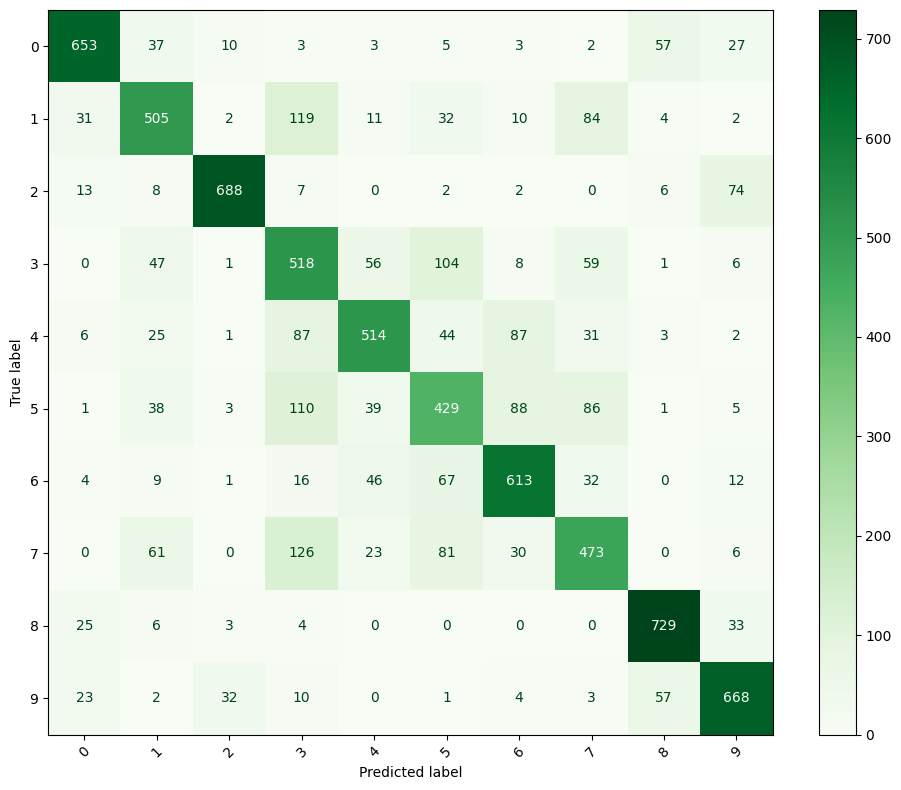

array([[653,  37,  10,   3,   3,   5,   3,   2,  57,  27],
       [ 31, 505,   2, 119,  11,  32,  10,  84,   4,   2],
       [ 13,   8, 688,   7,   0,   2,   2,   0,   6,  74],
       [  0,  47,   1, 518,  56, 104,   8,  59,   1,   6],
       [  6,  25,   1,  87, 514,  44,  87,  31,   3,   2],
       [  1,  38,   3, 110,  39, 429,  88,  86,   1,   5],
       [  4,   9,   1,  16,  46,  67, 613,  32,   0,  12],
       [  0,  61,   0, 126,  23,  81,  30, 473,   0,   6],
       [ 25,   6,   3,   4,   0,   0,   0,   0, 729,  33],
       [ 23,   2,  32,  10,   0,   1,   4,   3,  57, 668]])

In [65]:
test_confusion_matrix(model_pi_4500, test_loader, device)

### **Тест 2: кероване навчання (supervised) на 1000 мітках**
Цей блок є baseline-моделлю: вона використовує стандартну архітектуру ResNet-18, навчається тільки на розмічених даних без використання нерозмічених прикладів.

In [66]:
# ініціалізація моделі
# тут не використовуються попередньо навчені ваги SimCLR, щоб створити "чистий" baseline
def build_supervised_resnet18(num_classes=10, device="cpu"):
    """Створює стандартний ResNet-18 для навчання 'з нуля'"""
    model = models.resnet18(weights=None)
    # замінюємо останній повнозв'язний шар відповідно до кількості класів STL-10
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

# налаштування гіперпараметрів для baseline-експерименту
EPOCHS_SUP_1000 = 30
LR_SUP = 3e-4 # Трохи нижчий LR для стабільнішого навчання "з нуля"

# побудова моделі
model_sup_1000 = build_supervised_resnet18(num_classes=10, device=device)

# запуск навчання
# використано sup_loader_1000 (тільки 1000 розмічених прикладів)
hist_sup_1000, best_sup_1000 = train_supervised(
    model_sup_1000,
    train_loader=sup_loader_1000,
    val_loader=val_loader,
    device=device,
    epochs=EPOCHS_SUP_1000,
    lr=LR_SUP
)

# тестування моделі
test_sup_1000 = run_test_eval(model_sup_1000, test_loader, device, tag="SUP-1000")

Supervised ep 001 | Train Loss 2.2859 Acc 0.1758 | Val Loss 2.2149 Acc 0.2040 F1m 0.1501
Supervised ep 002 | Train Loss 1.8706 Acc 0.3268 | Val Loss 2.1206 Acc 0.1880 F1m 0.1185
Supervised ep 003 | Train Loss 1.7018 Acc 0.3841 | Val Loss 2.0796 Acc 0.2200 F1m 0.1449
Supervised ep 004 | Train Loss 1.5555 Acc 0.4375 | Val Loss 2.1118 Acc 0.2360 F1m 0.1679
Supervised ep 005 | Train Loss 1.3913 Acc 0.5117 | Val Loss 2.1239 Acc 0.2400 F1m 0.1911
Supervised ep 006 | Train Loss 1.2849 Acc 0.5573 | Val Loss 2.0250 Acc 0.2480 F1m 0.2092
Supervised ep 007 | Train Loss 1.1862 Acc 0.5951 | Val Loss 1.8396 Acc 0.3320 F1m 0.2746
Supervised ep 008 | Train Loss 1.0847 Acc 0.6107 | Val Loss 1.7393 Acc 0.3800 F1m 0.3379
Supervised ep 009 | Train Loss 0.9741 Acc 0.6615 | Val Loss 1.7181 Acc 0.3920 F1m 0.3716
Supervised ep 010 | Train Loss 0.8896 Acc 0.6979 | Val Loss 1.5444 Acc 0.4380 F1m 0.4010
Supervised ep 011 | Train Loss 0.8088 Acc 0.7422 | Val Loss 1.5928 Acc 0.4420 F1m 0.4190
Supervised ep 012 | T

Confusion matrix:


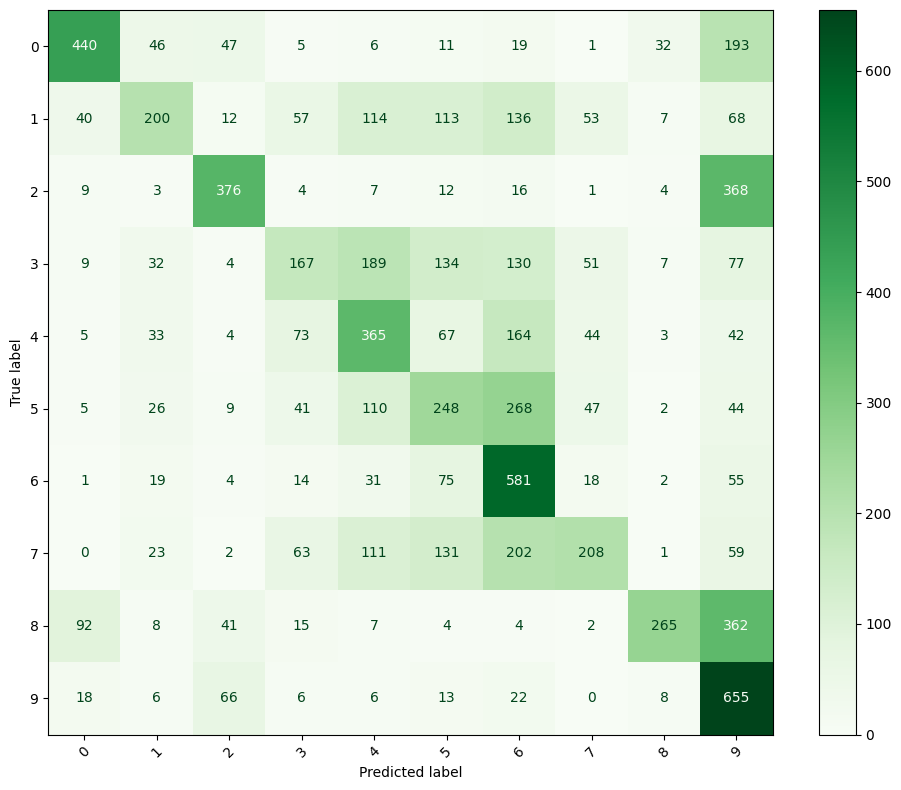

array([[440,  46,  47,   5,   6,  11,  19,   1,  32, 193],
       [ 40, 200,  12,  57, 114, 113, 136,  53,   7,  68],
       [  9,   3, 376,   4,   7,  12,  16,   1,   4, 368],
       [  9,  32,   4, 167, 189, 134, 130,  51,   7,  77],
       [  5,  33,   4,  73, 365,  67, 164,  44,   3,  42],
       [  5,  26,   9,  41, 110, 248, 268,  47,   2,  44],
       [  1,  19,   4,  14,  31,  75, 581,  18,   2,  55],
       [  0,  23,   2,  63, 111, 131, 202, 208,   1,  59],
       [ 92,   8,  41,  15,   7,   4,   4,   2, 265, 362],
       [ 18,   6,  66,   6,   6,  13,  22,   0,   8, 655]])

In [67]:
test_confusion_matrix(model_sup_1000, test_loader, device)

### **Тест 3: Напівкероване навчання (SimCLR + PI-model) на 1000 мітках**
Це головний результат роботи, що демонструє здатність моделі ефективно навчатися в умовах гострого дефіциту розмічених даних.


In [68]:
# побудова моделі з попередньо навченим SimCLR енкодером
# заморозка енкодера (freeze_encoder=True) дозволяє оцінити якість
# вивчених раніше представлень (features) при мінімальній кількості міток
model_pi_1000 = build_model(
    simclr_ckpt_path=SIMCLR_CKPT_PATH,
    projection_dim=128,
    num_classes=10,
    device=device,
    freeze_encoder=True,
)

# запуск напівкерованого тренування
# використовуємо лише 1000 міток (labeled_loader_pi_1000)
# у поєднанні з великим набором нерозмічених даних (unlabeled_loader)
hist_pi_1000, best_pi_1000 = train_pi(
    model_pi_1000,
    labeled_loader=labeled_loader_pi_1000,
    unlabeled_loader=unlabeled_loader,
    val_loader=val_loader,
    device=device,
    epochs=cfg.epochs_pi_1000,
    lr=cfg.lr_head,
    max_w=cfg.pi_max_w,
)

# підсумкова оцінка на тестовому наборі
test_pi_1000 = run_test_eval(model_pi_1000, test_loader, device, tag="PI-1000")

# вивід найкращих результатів епохи та фінального тестування
print("\nНайкраща епоха за даними валідації:", best_pi_1000)
print("Результати фінального тестування:", test_pi_1000)


[INFO] Енкодер успішно завантажено. Пропущено ключів: 0
[INFO] Модель побудовано. Треновані параметри: 5,130 / 11,181,642
[PI] Ep 001 | Lam 0.577 | Total Loss 2.4667 (Sup 2.4667 Cons 0.0002)
[PI] Ep 002 | Lam 1.457 | Total Loss 1.9873 (Sup 1.9871 Cons 0.0002)
[PI] Ep 003 | Lam 3.251 | Total Loss 1.6662 (Sup 1.6655 Cons 0.0002)
[PI] Ep 004 | Lam 6.411 | Total Loss 1.4275 (Sup 1.4257 Cons 0.0003)
[PI] Ep 005 | Lam 11.173 | Total Loss 1.2911 (Sup 1.2870 Cons 0.0004)
[PI] Ep 006 | Lam 17.213 | Total Loss 1.1458 (Sup 1.1368 Cons 0.0005)
[PI] Ep 007 | Lam 23.436 | Total Loss 1.0760 (Sup 1.0617 Cons 0.0006)
[PI] Ep 008 | Lam 28.204 | Total Loss 1.0254 (Sup 1.0070 Cons 0.0007)
[PI] Ep 009 | Lam 30.000 | Total Loss 0.9933 (Sup 0.9727 Cons 0.0007)
[PI] Ep 010 | Lam 30.000 | Total Loss 0.9537 (Sup 0.9282 Cons 0.0008)
[PI] Ep 011 | Lam 30.000 | Total Loss 0.9044 (Sup 0.8796 Cons 0.0008)
[PI] Ep 012 | Lam 30.000 | Total Loss 0.8984 (Sup 0.8665 Cons 0.0011)
[PI] Ep 013 | Lam 30.000 | Total Loss 0.8

Confusion matrix:


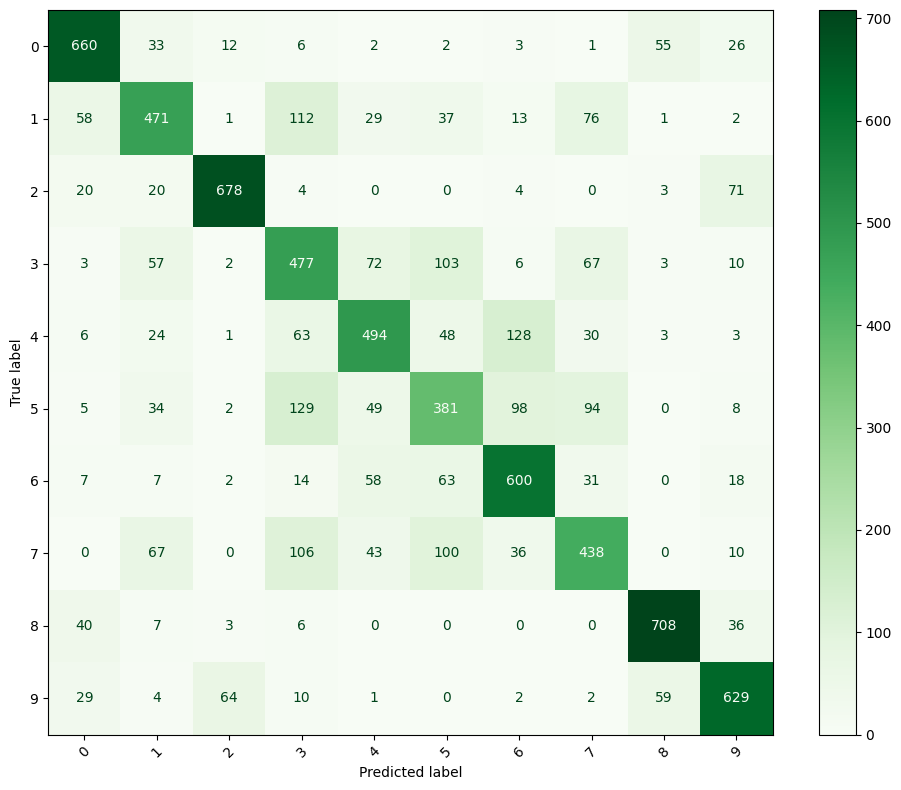

array([[660,  33,  12,   6,   2,   2,   3,   1,  55,  26],
       [ 58, 471,   1, 112,  29,  37,  13,  76,   1,   2],
       [ 20,  20, 678,   4,   0,   0,   4,   0,   3,  71],
       [  3,  57,   2, 477,  72, 103,   6,  67,   3,  10],
       [  6,  24,   1,  63, 494,  48, 128,  30,   3,   3],
       [  5,  34,   2, 129,  49, 381,  98,  94,   0,   8],
       [  7,   7,   2,  14,  58,  63, 600,  31,   0,  18],
       [  0,  67,   0, 106,  43, 100,  36, 438,   0,  10],
       [ 40,   7,   3,   6,   0,   0,   0,   0, 708,  36],
       [ 29,   4,  64,  10,   1,   0,   2,   2,  59, 629]])

In [69]:
test_confusion_matrix(model_pi_1000, test_loader, device)

### **Тест номер 4: кероване навчання (Supervised) на 4500 мітках**
Цей експеримент показує продуктивність моделі при використанні повного обсягу розмічених даних (Full Supervised Learning).

In [70]:
# налаштування гіперпараметрів
EPOCHS_SUP_4500 = 30
LR_SUP = 3e-4

# побудова моделі ResNet-18 (навчання "з нуля" без SimCLR-ваг)
model_sup_4500 = build_supervised_resnet18(num_classes=10, device=device)

# запуск керованого тренування
# використовується sup_loader_4500 (набір з 4500 розмічених прикладів)
hist_sup_4500, best_sup_4500 = train_supervised(
    model_sup_4500,
    train_loader=sup_loader_4500,
    val_loader=val_loader,
    device=device,
    epochs=EPOCHS_SUP_4500,
    lr=LR_SUP
)

# тестування моделі на тестовому наборі
test_sup_4500 = run_test_eval(model_sup_4500, test_loader, device, tag="SUP-4500")

# вивід результатів для подальшого аналізу
print("\nРезультати навчання на 4500 мітках (Baseline):")
print(f"Best validation acc: {best_sup_4500['val_acc']:.4f}")
print(f"Final test acc: {test_sup_4500['acc']:.4f}")

Supervised ep 001 | Train Loss 1.8428 Acc 0.3109 | Val Loss 1.8581 Acc 0.3280 F1m 0.2923
Supervised ep 002 | Train Loss 1.4513 Acc 0.4478 | Val Loss 1.6410 Acc 0.4040 F1m 0.3936
Supervised ep 003 | Train Loss 1.2640 Acc 0.5250 | Val Loss 1.4495 Acc 0.4740 F1m 0.4439
Supervised ep 004 | Train Loss 1.1089 Acc 0.5928 | Val Loss 1.3111 Acc 0.5340 F1m 0.5208
Supervised ep 005 | Train Loss 1.0216 Acc 0.6236 | Val Loss 1.3814 Acc 0.5180 F1m 0.4884
Supervised ep 006 | Train Loss 0.9192 Acc 0.6574 | Val Loss 1.2935 Acc 0.5500 F1m 0.5532
Supervised ep 007 | Train Loss 0.8081 Acc 0.7077 | Val Loss 1.3489 Acc 0.5300 F1m 0.5237
Supervised ep 008 | Train Loss 0.7363 Acc 0.7316 | Val Loss 1.2664 Acc 0.5540 F1m 0.5587
Supervised ep 009 | Train Loss 0.6635 Acc 0.7665 | Val Loss 1.2695 Acc 0.5580 F1m 0.5532
Supervised ep 010 | Train Loss 0.5841 Acc 0.7937 | Val Loss 1.6571 Acc 0.5160 F1m 0.5139
Supervised ep 011 | Train Loss 0.5594 Acc 0.8065 | Val Loss 1.4187 Acc 0.5620 F1m 0.5580
Supervised ep 012 | T

Confusion matrix:


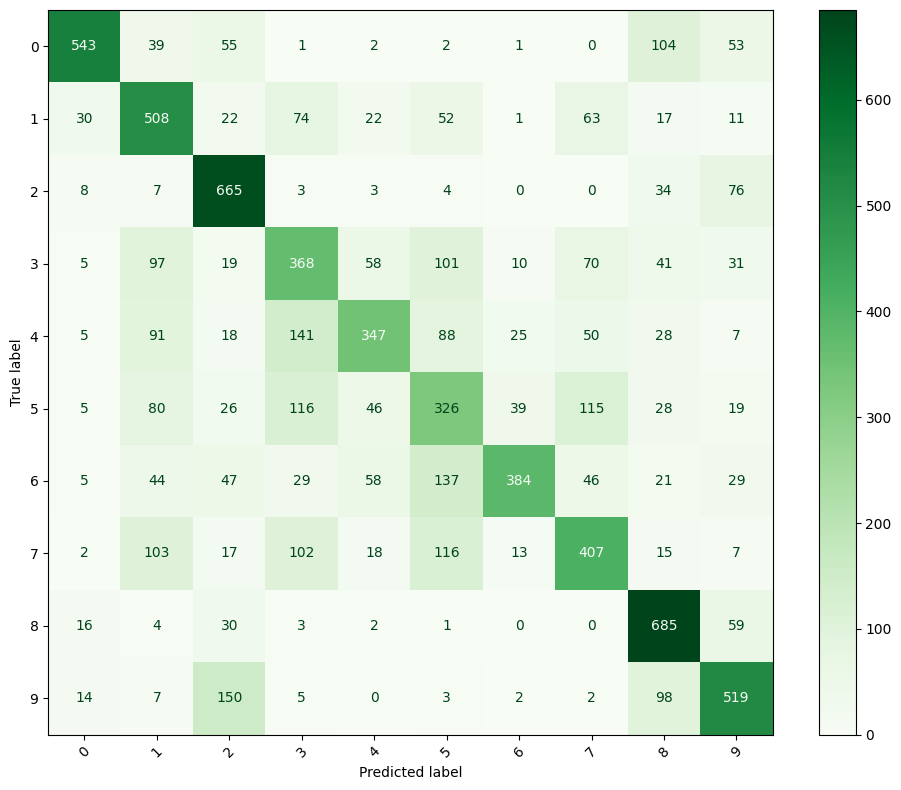

array([[543,  39,  55,   1,   2,   2,   1,   0, 104,  53],
       [ 30, 508,  22,  74,  22,  52,   1,  63,  17,  11],
       [  8,   7, 665,   3,   3,   4,   0,   0,  34,  76],
       [  5,  97,  19, 368,  58, 101,  10,  70,  41,  31],
       [  5,  91,  18, 141, 347,  88,  25,  50,  28,   7],
       [  5,  80,  26, 116,  46, 326,  39, 115,  28,  19],
       [  5,  44,  47,  29,  58, 137, 384,  46,  21,  29],
       [  2, 103,  17, 102,  18, 116,  13, 407,  15,   7],
       [ 16,   4,  30,   3,   2,   1,   0,   0, 685,  59],
       [ 14,   7, 150,   5,   0,   3,   2,   2,  98, 519]])

In [71]:
test_confusion_matrix(model_sup_4500, test_loader, device)

In [72]:
import pandas as pd
# створення підсумкової таблиці для порівняння метрик
summary = pd.DataFrame([
    {"run": "PI-4500", "best_val_acc": best_pi_4500["val_acc"], "best_val_f1_macro": best_pi_4500.get("val_f1_macro", None), "test_acc": test_pi_4500["acc"], "test_f1_macro": test_pi_4500.get("f1_macro", None)},
    {"run": "SUP-1000", "best_val_acc": best_sup_1000["val_acc"], "best_val_f1_macro": best_sup_1000.get("val_f1_macro", None), "test_acc": test_sup_1000["acc"], "test_f1_macro": test_sup_1000.get("f1_macro", None)},
    {"run": "PI-1000", "best_val_acc": best_pi_1000["val_acc"], "best_val_f1_macro": best_pi_1000.get("val_f1_macro", None), "test_acc": test_pi_1000["acc"], "test_f1_macro": test_pi_1000.get("f1_macro", None)},
]).sort_values("run")

print("Порівняльна таблиця результатів експериментів:")
display(summary)

Порівняльна таблиця результатів експериментів:


,run,best_val_acc,best_val_f1_macro,test_acc,test_f1_macro
2,PI-1000,0.686,0.688803,0.692000,0.690958
0,PI-4500,0.740,0.738624,0.723750,0.724610
1,SUP-1000,0.526,0.509164,0.438125,0.428580


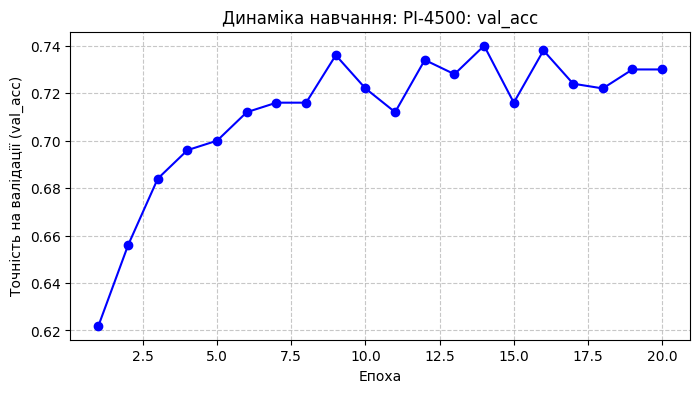

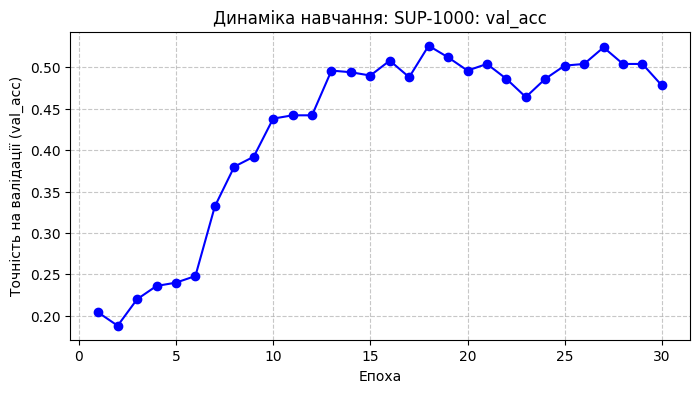

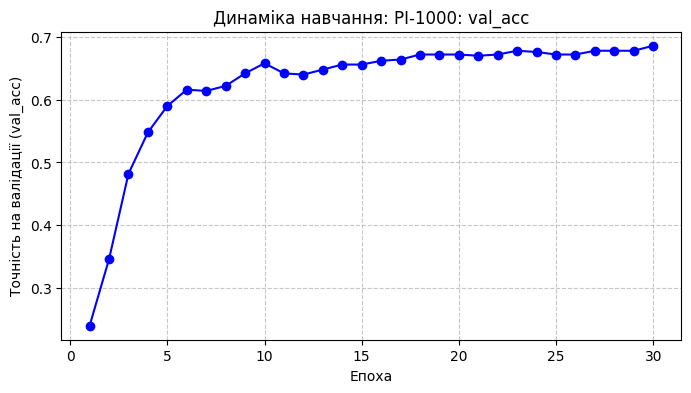

In [73]:
# --- візуалізація кривих навчання ---
def plot_curves(hist, title):
    """Будує графік динаміки зміни точності на валідації протягом епох"""
    df = pd.DataFrame(hist)
    plt.figure(figsize=(8, 4))
    plt.plot(df["epoch"], df["val_acc"], marker='o', linestyle='-', color='b')
    plt.xlabel("Епоха")
    plt.ylabel("Точність на валідації (val_acc)")
    plt.title(f"Динаміка навчання: {title}")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

plot_curves(hist_pi_4500, "PI-4500: val_acc")
plot_curves(hist_sup_1000, "SUP-1000: val_acc")
plot_curves(hist_pi_1000, "PI-1000: val_acc")


### **Тест номер 5: PI-модель на 1000 мітках (навчання "з нуля")**
Тут ми перевіряємо, чи допомагає PI-model сама по собі, без використання попередньо навчених ваг SimCLR. Це допомагає оцінити "чистий" внесок контрастивного навчання (SimCLR) у загальний результат.

In [74]:
def train_pi_from_scratch_1000(
    epochs=30,
    lr=3e-4,
    weight_decay=1e-4,
    max_w=20.0,
    rampup_frac=0.3,
    print_every=1,
):
    """Тренування PI-моделі на ResNet-18 'з нуля' (без SimCLR)"""
    # ініціалізація ваг випадковим чином
    model = build_supervised_resnet18(num_classes=10, device=device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    ce = nn.CrossEntropyLoss()

    rampup_epochs = int(rampup_frac * epochs)
    best = {"val_acc": -1.0, "epoch": 0, "state": None, "val": None}

    for ep in range(1, epochs + 1):
        model.train()
        # розрахунок поточної ваги consistency loss
        lam = rampup_weight(ep - 1, rampup_epochs, max_w)
        running, running_sup, running_cons, seen = 0.0, 0.0, 0.0, 0

        unl_it = iter(unlabeled_loader)

        for (x1, x2, y) in labeled_loader_pi_1000:
            # обробка нерозмічених даних через ітератор
            try:
                u1, u2, _ = next(unl_it)
            except StopIteration:
                unl_it = iter(unlabeled_loader)
                u1, u2, _ = next(unl_it)

            x1, x2, y = x1.to(device), x2.to(device), y.to(device)
            u1, u2 = u1.to(device), u2.to(device)

            opt.zero_grad(set_to_none=True)

            # Supervised Loss (на розмічених даних)
            logits_x1 = model(x1)
            sup_loss = ce(logits_x1, y)

            # Consistency Loss (MSE між двома поглядами нерозмічених даних)
            logits_u1, logits_u2 = model(u1), model(u2)
            cons_loss = consistency_mse(logits_u1, logits_u2)

            # загальна функція втрат
            loss = sup_loss + lam * cons_loss
            loss.backward()
            opt.step()

            bs = x1.size(0)
            running += loss.item() * bs
            running_sup += sup_loss.item() * bs
            running_cons += cons_loss.item() * bs
            seen += bs

        # валідація
        val = evaluate(model, val_loader, device)
        if val["acc"] > best["val_acc"]:
            best.update({"val_acc": val["acc"], "epoch": ep, "val": val})

        if ep % print_every == 0:
            print(f"PI-1000 (scratch) ep {ep:03d} | Lam {lam:.3f} | Loss {running/seen:.4f} "
                  f"(Sup {running_sup/seen:.4f} Cons {running_cons/seen:.4f}) | "
                  f"Val Acc {val['acc']:.4f}")

    test = evaluate(model, test_loader, device)
    print(f"\n[PI-SCRATCH-1000] BEST val@ep {best['epoch']:03d}: Acc {best['val']['acc']:.4f}")
    print(f"[PI-SCRATCH-1000] TEST: Acc {test['acc']:.4f} F1m {test['f1_macro']:.4f}")

    return model, best, test

model_pi_scratch_1000, best_pi_scratch_1000, test_pi_scratch_1000 = train_pi_from_scratch_1000(
    epochs=30,
    lr=3e-4,
    weight_decay=1e-4,
    max_w=20.0,
    rampup_frac=0.3
)

PI-1000 (scratch) ep 001 | Lam 0.135 | Loss 2.2364 (Sup 2.2363 Cons 0.0009) | Val Acc 0.1680
PI-1000 (scratch) ep 002 | Lam 0.385 | Loss 1.8452 (Sup 1.8446 Cons 0.0016) | Val Acc 0.1540
PI-1000 (scratch) ep 003 | Lam 0.971 | Loss 1.6753 (Sup 1.6730 Cons 0.0023) | Val Acc 0.2540
PI-1000 (scratch) ep 004 | Lam 2.167 | Loss 1.5431 (Sup 1.5367 Cons 0.0029) | Val Acc 0.3540
PI-1000 (scratch) ep 005 | Lam 4.274 | Loss 1.4918 (Sup 1.4790 Cons 0.0030) | Val Acc 0.3860
PI-1000 (scratch) ep 006 | Lam 7.449 | Loss 1.3398 (Sup 1.3128 Cons 0.0036) | Val Acc 0.3640
PI-1000 (scratch) ep 007 | Lam 11.475 | Loss 1.3165 (Sup 1.2642 Cons 0.0046) | Val Acc 0.4040
PI-1000 (scratch) ep 008 | Lam 15.624 | Loss 1.2444 (Sup 1.1700 Cons 0.0048) | Val Acc 0.4160
PI-1000 (scratch) ep 009 | Lam 18.803 | Loss 1.1567 (Sup 1.0598 Cons 0.0051) | Val Acc 0.4480
PI-1000 (scratch) ep 010 | Lam 20.000 | Loss 1.1143 (Sup 1.0054 Cons 0.0054) | Val Acc 0.4480
PI-1000 (scratch) ep 011 | Lam 20.000 | Loss 1.0402 (Sup 0.9165 Co

Confusion matrix:


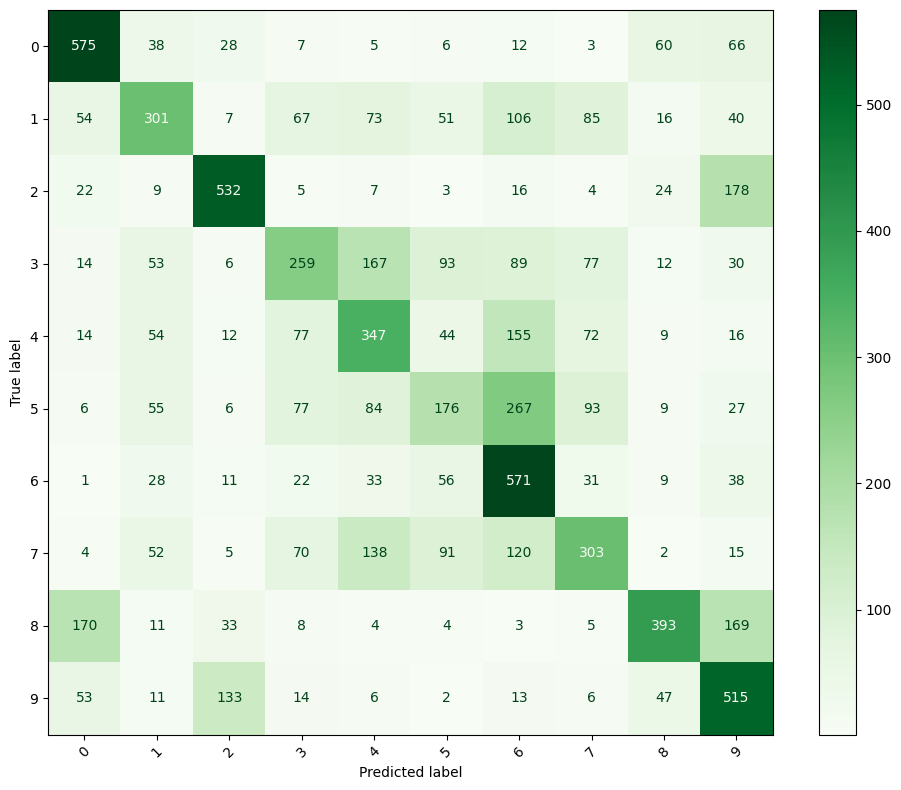

array([[575,  38,  28,   7,   5,   6,  12,   3,  60,  66],
       [ 54, 301,   7,  67,  73,  51, 106,  85,  16,  40],
       [ 22,   9, 532,   5,   7,   3,  16,   4,  24, 178],
       [ 14,  53,   6, 259, 167,  93,  89,  77,  12,  30],
       [ 14,  54,  12,  77, 347,  44, 155,  72,   9,  16],
       [  6,  55,   6,  77,  84, 176, 267,  93,   9,  27],
       [  1,  28,  11,  22,  33,  56, 571,  31,   9,  38],
       [  4,  52,   5,  70, 138,  91, 120, 303,   2,  15],
       [170,  11,  33,   8,   4,   4,   3,   5, 393, 169],
       [ 53,  11, 133,  14,   6,   2,  13,   6,  47, 515]])

In [75]:
test_confusion_matrix(model_pi_scratch_1000, test_loader, device)

### **Тест номер 6: PI-модель на 4500 мітках (навчання "з нуля")**
Це дослідження допомагає зрозуміти, чи дає додавання consistency loss перевагу
навіть тоді, коли розмічених даних достатньо для стандартного навчання.

In [76]:
def train_pi_from_scratch_4500(
    epochs=30,
    lr=3e-4,
    weight_decay=1e-4,
    max_w=20.0,
    rampup_frac=0.3,
    print_every=1,
):
    """Тренування PI-моделі на 4500 прикладах без використання SimCLR-енкодера"""
    # ініціалізація ваг випадковим чином
    model = build_supervised_resnet18(num_classes=10, device=device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    ce = nn.CrossEntropyLoss()

    rampup_epochs = int(rampup_frac * epochs)
    best = {"val_acc": -1.0, "epoch": 0, "state": None, "val": None}

    for ep in range(1, epochs + 1):
        model.train()
        # поступове збільшення ваги для consistency loss
        lam = rampup_weight(ep - 1, rampup_epochs, max_w)
        running, running_sup, running_cons, seen = 0.0, 0.0, 0.0, 0

        unl_it = iter(unlabeled_loader)

        # використовуємо 4500 розмічених прикладів
        for (x1, x2, y) in labeled_loader_pi_4500:
            try:
                u1, u2, _ = next(unl_it)
            except StopIteration:
                unl_it = iter(unlabeled_loader)
                u1, u2, _ = next(unl_it)

            x1, x2, y = x1.to(device), x2.to(device), y.to(device)
            u1, u2 = u1.to(device), u2.to(device)

            opt.zero_grad(set_to_none=True)

            # розрахунок втрат: поєднання крос-ентропії та consistency loss
            logits_x1 = model(x1)
            sup_loss = ce(logits_x1, y)

            logits_u1, logits_u2 = model(u1), model(u2)
            cons_loss = consistency_mse(logits_u1, logits_u2)

            loss = sup_loss + lam * cons_loss
            loss.backward()
            opt.step()

            bs = x1.size(0)
            running += loss.item() * bs
            running_sup += sup_loss.item() * bs
            running_cons += cons_loss.item() * bs
            seen += bs

        # оцінка результативності
        val = evaluate(model, val_loader, device)
        if val["acc"] > best["val_acc"]:
            best.update({"val_acc": val["acc"], "epoch": ep, "val": val})

        if ep % print_every == 0:
            print(f"PI-4500 (scratch) ep {ep:03d} | Lam {lam:.3f} | Loss {running/seen:.4f} "
                  f"(Sup {running_sup/seen:.4f} Cons {running_cons/seen:.4f}) | Val Acc {val['acc']:.4f}")

    # фінальне тестування
    test = evaluate(model, test_loader, device)
    print(f"\n[PI-SCRATCH-4500] BEST val@ep {best['epoch']:03d}: Acc {best['val']['acc']:.4f}")
    print(f"[PI-SCRATCH-4500] TEST: Acc {test['acc']:.4f} F1m {test['f1_macro']:.4f}")

    return model, best, test

# запуск тесту
model_pi_scratch_4500, best_pi_scratch_4500, test_pi_scratch_4500 = train_pi_from_scratch_4500(
    epochs=30,
    lr=3e-4,
    weight_decay=1e-4,
    max_w=20.0,
    rampup_frac=0.3
)

PI-4500 (scratch) ep 001 | Lam 0.135 | Loss 1.8252 (Sup 1.8249 Cons 0.0020) | Val Acc 0.4100
PI-4500 (scratch) ep 002 | Lam 0.385 | Loss 1.4422 (Sup 1.4406 Cons 0.0040) | Val Acc 0.4740
PI-4500 (scratch) ep 003 | Lam 0.971 | Loss 1.2607 (Sup 1.2553 Cons 0.0056) | Val Acc 0.5100
PI-4500 (scratch) ep 004 | Lam 2.167 | Loss 1.1409 (Sup 1.1265 Cons 0.0066) | Val Acc 0.5400
PI-4500 (scratch) ep 005 | Lam 4.274 | Loss 1.0377 (Sup 1.0052 Cons 0.0076) | Val Acc 0.5680
PI-4500 (scratch) ep 006 | Lam 7.449 | Loss 0.9751 (Sup 0.9147 Cons 0.0081) | Val Acc 0.5660
PI-4500 (scratch) ep 007 | Lam 11.475 | Loss 0.9047 (Sup 0.8133 Cons 0.0080) | Val Acc 0.6180
PI-4500 (scratch) ep 008 | Lam 15.624 | Loss 0.8776 (Sup 0.7591 Cons 0.0076) | Val Acc 0.5720
PI-4500 (scratch) ep 009 | Lam 18.803 | Loss 0.8120 (Sup 0.6857 Cons 0.0067) | Val Acc 0.5800
PI-4500 (scratch) ep 010 | Lam 20.000 | Loss 0.7652 (Sup 0.6233 Cons 0.0071) | Val Acc 0.6100
PI-4500 (scratch) ep 011 | Lam 20.000 | Loss 0.7076 (Sup 0.5596 Co

Confusion matrix:


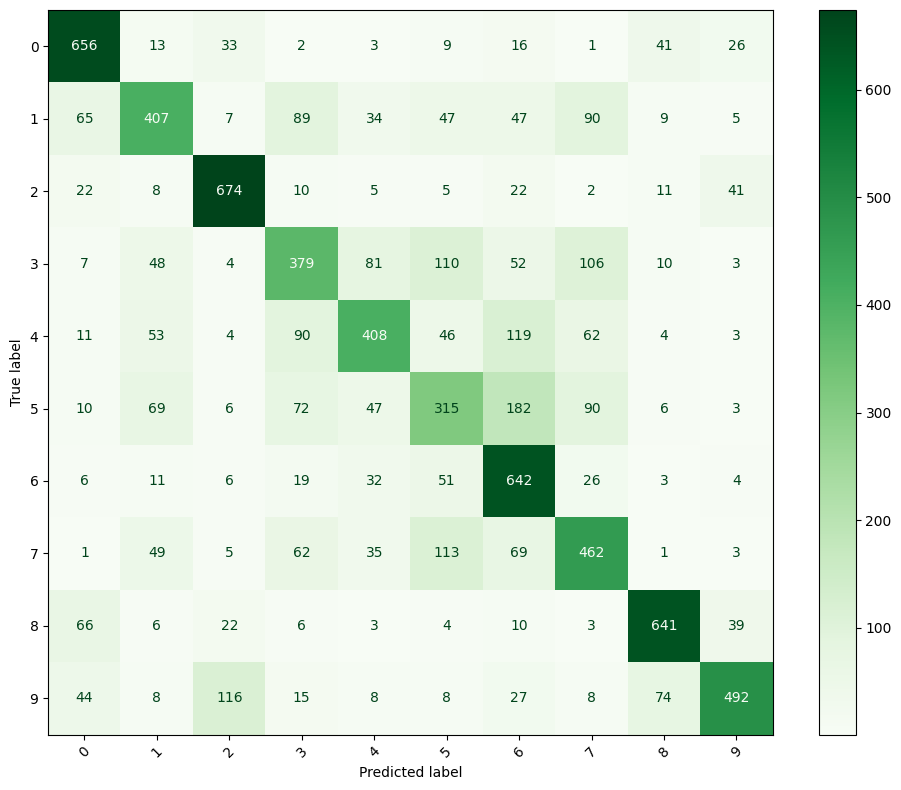

array([[656,  13,  33,   2,   3,   9,  16,   1,  41,  26],
       [ 65, 407,   7,  89,  34,  47,  47,  90,   9,   5],
       [ 22,   8, 674,  10,   5,   5,  22,   2,  11,  41],
       [  7,  48,   4, 379,  81, 110,  52, 106,  10,   3],
       [ 11,  53,   4,  90, 408,  46, 119,  62,   4,   3],
       [ 10,  69,   6,  72,  47, 315, 182,  90,   6,   3],
       [  6,  11,   6,  19,  32,  51, 642,  26,   3,   4],
       [  1,  49,   5,  62,  35, 113,  69, 462,   1,   3],
       [ 66,   6,  22,   6,   3,   4,  10,   3, 641,  39],
       [ 44,   8, 116,  15,   8,   8,  27,   8,  74, 492]])

In [77]:
test_confusion_matrix(model_pi_scratch_4500, test_loader, device)